# Предобработка данных и формирование целевой переменной

В данном ноутбуке выполняется подготовка набора данных NHANES к задаче прогнозирования качества сна. 
Реализуются преобразование типов данных, сортировка наблюдений, построение бинарной целевой переменной и лаговых признаков, а также формирование первой модельной таблицы без прямой утечки информации.

## Импортируем и делаем первичное преобразование

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

from src.config import RAW_DATA_PATH, PROCESSED_DATA_PATH, MODEL_DATA_PATH

df = pd.read_csv(RAW_DATA_PATH)

df["calendar_date"] = pd.to_datetime(df["calendar_date"], errors="coerce")
df = df.dropna(subset=["SEQN", "calendar_date", "sleep_efficiency"])
df = df.sort_values(["SEQN", "calendar_date"]).reset_index(drop=True)

print(df.shape)
df.head()

(89104, 42)


,SEQN,weekday,dayofweek,calendar_date,guider,window_number,night_number,nonwear_perc_day,nonwear_perc_spt,nonwear_perc_day_spt,...,dur_spt_wake_MOD_min,dur_spt_wake_VIG_min,dur_day_min,dur_spt_min,dur_day_spt_min,ACC_spt_sleep_mg,excluded,mec4yr,SDMVPSU,SDMVSTRA
0,62161,Sunday,1,2000-01-09,HDCZA,1,2,0.0,0.0,0.0,...,0,0,876,477,1353,6.743,0,52118.291277,1,91
1,62161,Monday,2,2000-01-10,HDCZA,2,3,0.0,0.0,0.0,...,0,0,942,496,1438,3.550,0,52118.291277,1,91
2,62161,Tuesday,3,2000-01-11,HDCZA,3,4,0.0,0.0,0.0,...,0,0,896,546,1442,3.243,0,52118.291277,1,91
3,62161,Wednesday,4,2000-01-12,HDCZA,4,5,0.0,0.0,0.0,...,0,0,902,538,1440,5.848,0,52118.291277,1,91
4,62161,Thursday,5,2000-01-13,HDCZA,5,6,0.0,0.0,0.0,...,0,0,966,599,1565,8.036,0,52118.291277,1,91


## Распределение таргета

count    89104.000000
mean         0.839512
std          0.168396
min          0.000000
10%          0.749000
25%          0.820000
50%          0.875000
75%          0.919000
90%          0.951000
max          1.000000
Name: sleep_efficiency, dtype: float64


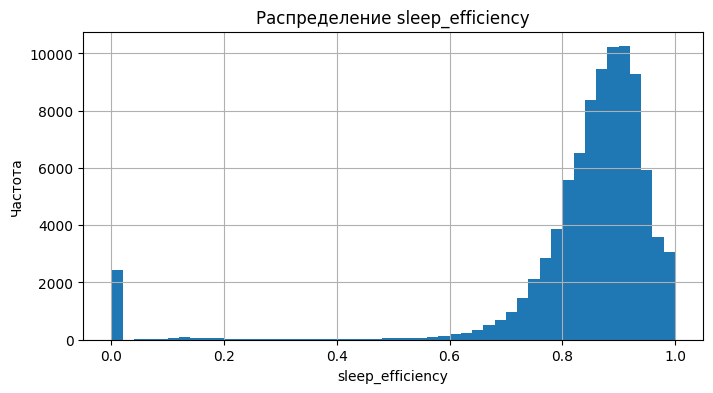

In [5]:
import matplotlib.pyplot as plt

print(df["sleep_efficiency"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

plt.figure(figsize=(8, 4))
df["sleep_efficiency"].hist(bins=50)
plt.title("Распределение sleep_efficiency")
plt.xlabel("sleep_efficiency")
plt.ylabel("Частота")
plt.show()

Для превой итерации будем использовать порог классификации 0.85

In [8]:
threshold = 0.85

df["target_bad_sleep"] = (df["sleep_efficiency"] < threshold).astype("int8")

print(df["target_bad_sleep"].value_counts(normalize=True))

target_bad_sleep
0    0.630847
1    0.369153
Name: proportion, dtype: float64


## Исключаем текущую утечку
Нельзя использовать в признаках текущие показатели той же ночи, которую предсказываем.

Для первой версии будем делать так:
- текущий sleep_efficiency — только target;
- все сонные/ночные показатели используем только в виде лагов;
- текущими оставляем только безопасные календарные признаки.

In [10]:
current_safe_cols = [
    "SEQN",
    "calendar_date",
    "weekday",
    "dayofweek",
    "window_number",
    "night_number"
]

lag_source_cols = [
    "sleep_efficiency",
    "nonwear_perc_day",
    "nonwear_perc_spt",
    "nonwear_perc_day_spt",
    "sleeponset",
    "wakeup",
    "L5VALUE",
    "L5TIME_num",
    "M5VALUE",
    "M5TIME_num",
    "L10VALUE",
    "L10TIME_num",
    "M10VALUE",
    "M10TIME_num",
    "dur_spt_sleep_min",
    "dur_spt_wake_IN_min",
    "dur_spt_wake_LIG_min",
    "dur_spt_wake_MOD_min",
    "dur_spt_wake_VIG_min",
    "dur_day_min",
    "dur_spt_min",
    "dur_day_spt_min",
    "ACC_spt_sleep_mg",
    "excluded"
]

Построим лаги 1,2 и 3 дня

In [11]:
for lag in [1, 2, 3]:
    for col in lag_source_cols:
        df[f"{col}_lag{lag}"] = df.groupby("SEQN")[col].shift(lag)

## Добавляем простые календарные признаки

In [12]:
df["month"] = df["calendar_date"].dt.month
df["day"] = df["calendar_date"].dt.day
df["dayofyear"] = df["calendar_date"].dt.dayofyear

## Собираем первую модельную таблицу

In [13]:
lag_feature_cols = []

for lag in [1, 2, 3]:
    lag_feature_cols.extend([f"{col}_lag{lag}" for col in lag_source_cols])

model_cols = (
    current_safe_cols
    + ["month", "day", "dayofyear", "target_bad_sleep"]
    + lag_feature_cols
)

model_df = df[model_cols].copy()

print("Размер модельной таблицы до удаления первых лагов:", model_df.shape)
model_df.head()

Размер модельной таблицы до удаления первых лагов: (89104, 82)


,SEQN,calendar_date,weekday,dayofweek,window_number,night_number,month,day,dayofyear,target_bad_sleep,...,dur_spt_sleep_min_lag3,dur_spt_wake_IN_min_lag3,dur_spt_wake_LIG_min_lag3,dur_spt_wake_MOD_min_lag3,dur_spt_wake_VIG_min_lag3,dur_day_min_lag3,dur_spt_min_lag3,dur_day_spt_min_lag3,ACC_spt_sleep_mg_lag3,excluded_lag3
0,62161,2000-01-09,Sunday,1,1,2,1,9,9,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,62161,2000-01-10,Monday,2,2,3,1,10,10,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62161,2000-01-11,Tuesday,3,3,4,1,11,11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,62161,2000-01-12,Wednesday,4,4,5,1,12,12,1,...,436.0,39.0,2.0,0.0,0.0,876.0,477.0,1353.0,6.743,0.0
4,62161,2000-01-13,Thursday,5,5,6,1,13,13,1,...,403.0,92.0,1.0,0.0,0.0,942.0,496.0,1438.0,3.550,0.0


Первые 1–3 записи по каждому человеку не имеют полной истории.
Для первой версии разумно оставить только строки, где есть хотя бы лаги по sleep_efficiency

In [14]:
model_df = model_df.dropna(
    subset=[
        "sleep_efficiency_lag1",
        "sleep_efficiency_lag2",
        "sleep_efficiency_lag3"
    ]
).reset_index(drop=True)

print("Размер модельной таблицы после фильтрации:", model_df.shape)

Размер модельной таблицы после фильтрации: (47523, 82)


In [16]:
model_missing = model_df.isna().sum().sort_values(ascending=False)
print(model_missing[model_missing > 0])

L10VALUE_lag1       194
L10TIME_num_lag1    194
M10VALUE_lag1       194
M10TIME_num_lag1    194
L10VALUE_lag3       189
L10TIME_num_lag3    189
M10VALUE_lag3       189
M10TIME_num_lag3    189
L10VALUE_lag2       181
L10TIME_num_lag2    181
M10VALUE_lag2       181
M10TIME_num_lag2    181
M5TIME_num_lag1      61
M5VALUE_lag1         61
L5VALUE_lag1         61
L5TIME_num_lag1      61
L5VALUE_lag2         51
L5TIME_num_lag2      51
M5VALUE_lag3         51
M5TIME_num_lag3      51
L5VALUE_lag3         51
L5TIME_num_lag3      51
M5VALUE_lag2         51
M5TIME_num_lag2      51
dtype: int64


In [17]:
df.to_csv(PROCESSED_DATA_PATH, index=False)
model_df.to_csv(MODEL_DATA_PATH, index=False)